In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../resources/sample_data/Iris.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print(df.nunique())
print(df.isnull().sum())
print(df.isna().sum())

Id               150
SepalLengthCm     35
SepalWidthCm      23
PetalLengthCm     43
PetalWidthCm      22
Species            3
dtype: int64
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


Because column Id is not related in datasets so we dropped

In [5]:
df.drop(columns="Id", inplace=True)

In [6]:
# OHE basic method
categories = pd.get_dummies(df.Species, dtype=int)
new_df = pd.concat([df, categories], axis=1)
new_df = new_df.drop(columns="Species")
new_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [7]:
datasets = new_df.values
datasets

# Now select index 0 until 3 for train, and the rest is label/feature

array([[5.1, 3.5, 1.4, ..., 1. , 0. , 0. ],
       [4.9, 3. , 1.4, ..., 1. , 0. , 0. ],
       [4.7, 3.2, 1.3, ..., 1. , 0. , 0. ],
       ...,
       [6.5, 3. , 5.2, ..., 0. , 0. , 1. ],
       [6.2, 3.4, 5.4, ..., 0. , 0. , 1. ],
       [5.9, 3. , 5.1, ..., 0. , 0. , 1. ]])

In [8]:
X = datasets[:,0:4]
y = datasets[:,4:7]

In [9]:
scaler = MinMaxScaler()
X_scale = scaler.fit_transform(X)
X_scale

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size=0.3)

In [11]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(4,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="Adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model_history = model.fit(X_train, y_train, epochs=230)

Epoch 1/230


4/4 [==============================] - 3s 11ms/step - loss: 1.0845 - accuracy: 0.3619
Epoch 2/230
4/4 [==============================] - 0s 7ms/step - loss: 1.0748 - accuracy: 0.3619
Epoch 3/230
4/4 [==============================] - 0s 7ms/step - loss: 1.0643 - accuracy: 0.3619
Epoch 4/230
4/4 [==============================] - 0s 6ms/step - loss: 1.0563 - accuracy: 0.3619
Epoch 5/230
4/4 [==============================] - 0s 7ms/step - loss: 1.0475 - accuracy: 0.3619
Epoch 6/230
4/4 [==============================] - 0s 7ms/step - loss: 1.0382 - accuracy: 0.3619
Epoch 7/230
4/4 [==============================] - 0s 7ms/step - loss: 1.0297 - accuracy: 0.3619
Epoch 8/230
4/4 [==============================] - 0s 8ms/step - loss: 1.0213 - accuracy: 0.3619
Epoch 9/230
4/4 [==============================] - 0s 7ms/step - loss: 1.0111 - accuracy: 0.3619
Epoch 10/230
4/4 [==============================] - 0s 6ms/step - loss: 1.0006 - accuracy: 0.3619
Epoch 11/230
4/4 [========

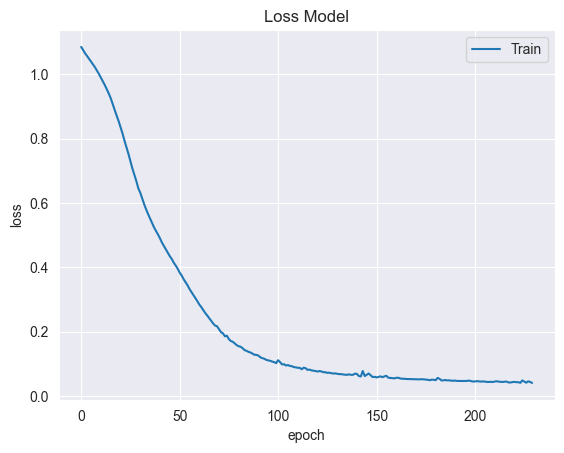

In [13]:
plt.plot(model_history.history["loss"])
plt.title("Loss Model")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["Train"], loc="upper right")
plt.show()

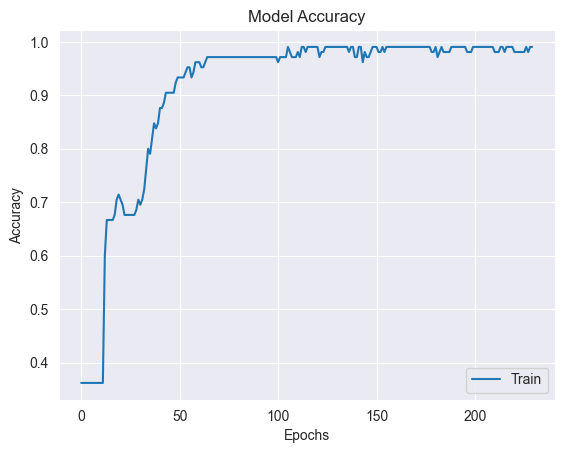

In [14]:
plt.plot(model_history.history["accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train"], loc="lower right")
plt.show()

In [15]:
model.evaluate(X_test, y_test, batch_size=1)

45/45 [==============================] - 1s 4ms/step - loss: 0.0761 - accuracy: 0.9333


[0.07614608108997345, 0.9333333373069763]

In [17]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [19]:
# First try predict with training data (try check one of index in dataset)

one_of_by_index = df.loc[1].drop("Species").values.reshape(1, -1)
one_of_by_index = scaler.transform(one_of_by_index)

pred = model.predict([one_of_by_index])
names = {idx: col for idx,col in enumerate(categories.columns)}
result = np.argmax(pred[0])

print(f"Prediction result: {names[result]}")

1/1 [==============================] - 0s 73ms/step
Prediction result: Iris-setosa
